In [1]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np
from atmo3 import grid_utils as gutl
from atmo3 import box
from atmo3 import atm_utils as au
from atmo3 import constants as const
import matplotlib.pyplot as plt

In [2]:
# N, Lbox, site_altitude...
N = jnp.array([512, 512, 512])                 # Number of grid points in each dimension
Lbox = jnp.array([5000.0, 5000.0, 8000.0])     # Box size in each dimension (in meters)
site_altitude = 5100.0                         # SO site altitude in meters

# Turbulence Parameters
L_0_c = 500.0                                 # Outer scale of turbulence in meters for the clouds
lambda_cutoff = 50.0                          # NEW: Minimum cloud structure size in meters

# Initialize the standalone grid workspace
grid_wsp = gutl.GridWorkspace(N=N, Lbox=Lbox, site_altitude=site_altitude)

z_axis_grid = grid_wsp.grid_axis(axis=2, altitude_axis=True)

cube_seed = 123456789

kx_max = (grid_wsp.N[0] / 2.0) * grid_wsp.dk[0]
ky_max = (grid_wsp.N[1] / 2.0) * grid_wsp.dk[1]
kz_max = (grid_wsp.N[2] / 2.0) * grid_wsp.dk[2]

# 2. Calculate the extreme corner of the 3D Fourier volume
k_max_3d = np.sqrt(kx_max**2 + ky_max**2 + kz_max**2)

# 3. Create a high-resolution k_array using the smallest dk step
dk_min = np.min(grid_wsp.dk)
n_points = int(k_max_3d / dk_min) + 10  # +10 acts as a safety buffer

k_array = np.arange(n_points) * dk_min

# --- Define the Wavenumbers ---
k0_c = 2 * np.pi / L_0_c           # Injection wavenumber (rad/m)
k_cutoff = 2 * np.pi / lambda_cutoff # NEW: Cutoff wavenumber (rad/m)

# --- Compute the Modified Power Spectrum ---
# 1. Base Kolmogorov-like spectrum
pofk_c_base  = (k0_c**2. + k_array**2)**-(11/6)

# 2. Apply the smooth Gaussian high-frequency cutoff
pofk_c = pofk_c_base * np.exp(-(k_array / k_cutoff)**2)


# Pack into dictionaries expected
pspec_c  = {'k': k_array, 'pofk': pofk_c}

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_680828/4155381558.py:9: SyntaxWarning: invalid escape sequence '\l'
  ax.loglog(k_array, pofk_c, color='crimson', lw=2, linestyle='--', label=f'Modified Spectrum ($\lambda_{{cutoff}}$ = {lambda_cutoff} m)')


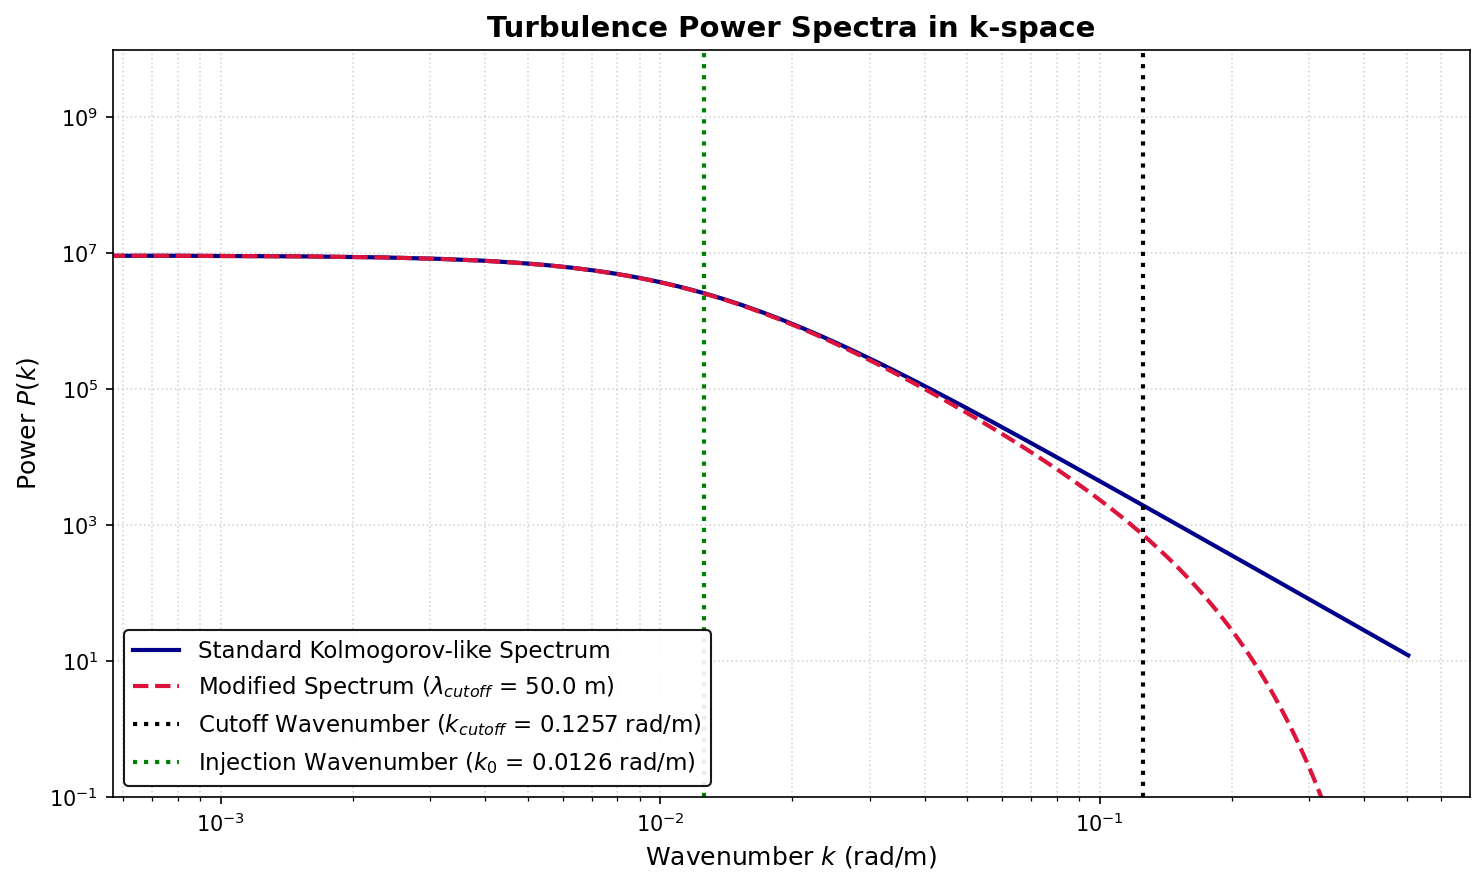

In [3]:
import matplotlib.pyplot as plt

# --- Plotting the Power Spectra in k-space ---

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

# Plot both spectra on a log-log scale
ax.loglog(k_array, pofk_c_base, color='darkblue', lw=2, label='Standard Kolmogorov-like Spectrum')
ax.loglog(k_array, pofk_c, color='crimson', lw=2, linestyle='--', label=f'Modified Spectrum ($\lambda_{{cutoff}}$ = {lambda_cutoff} m)')

# Draw a vertical line showing exactly where the cutoff wavenumber is located
ax.axvline(k_cutoff, color='black', linestyle=':', lw=2, label=f'Cutoff Wavenumber ($k_{{cutoff}}$ = {k_cutoff:.4f} rad/m)')
ax.axvline(k0_c, color='green', linestyle=':', lw=2, label=f'Injection Wavenumber ($k_{{0}}$ = {k0_c:.4f} rad/m)')

# Formatting
ax.set_title('Turbulence Power Spectra in k-space', fontsize=14, weight='bold')
ax.set_xlabel('Wavenumber $k$ (rad/m)', fontsize=12)
ax.set_ylabel('Power $P(k)$', fontsize=12)

# Grid and Legend
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend(loc='lower left', fontsize=11, framealpha=0.9, edgecolor='black')

ax.set_ylim(1e-1, 1e10)

plt.tight_layout()
plt.show()

In [4]:
cloud_box = box.Box(
    grid_wsp=grid_wsp,
    field_name='Turbulence for clouds',
    field_unit='No unit',
    spectrum=pspec_c, 
    zscaling={'h': z_axis_grid, 'f': jnp.ones_like(z_axis_grid)},  # No scaling with altitude
    seed=cube_seed 
)

cloud_box.generate_field_fluctuations(time_step=0)

Random field : 10.225185 s
Apply P(k) : 13.002366 s
IRFFT : 0.099476 s
Rescaled field : 2.642289 s


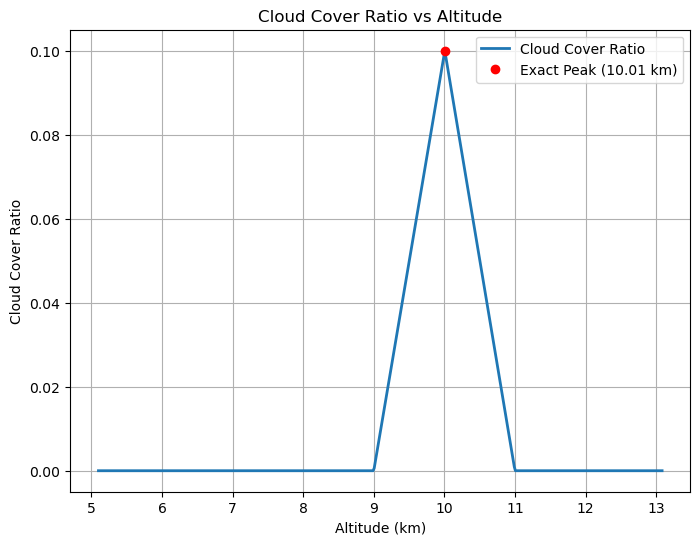

In [5]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

# --- 1. Define Parameters ---
cc_peak = 0.1
z_bottom = 9000.0
desired_z_peak = 10000.0
z_top = 11000.0

# --- 2. Snap the Peak to the Exact Grid ---
# Find the index of the grid altitude closest to 10000.0
peak_idx = jnp.argmin(jnp.abs(z_axis_grid - desired_z_peak))
# Reassign z_peak to be that exact grid altitude
actual_z_peak = z_axis_grid[peak_idx]

# --- 3. Build the Profile ---
cloud_cover_ratio = jnp.zeros_like(z_axis_grid)

# Ascending slope (z_bottom to actual_z_peak)
# Note the <= actual_z_peak here to ensure the peak is explicitly calculated
cloud_cover_ratio = jnp.where(
    (z_axis_grid >= z_bottom) & (z_axis_grid <= actual_z_peak),
    (z_axis_grid - z_bottom) / (actual_z_peak - z_bottom) * cc_peak,
    cloud_cover_ratio
)

# Descending slope (actual_z_peak to z_top)
cloud_cover_ratio = jnp.where(
    (z_axis_grid > actual_z_peak) & (z_axis_grid <= z_top),
    (z_top - z_axis_grid) / (z_top - actual_z_peak) * cc_peak,
    cloud_cover_ratio
)

# --- 4. Plot ---
plt.figure(figsize=(8, 6))
# Convert to km just for the plot axis
plt.plot(z_axis_grid / 1000, cloud_cover_ratio, label='Cloud Cover Ratio', lw=2)
# Add a dot to prove the peak hits exactly cc_peak
plt.plot(actual_z_peak / 1000, cc_peak, 'ro', label=f'Exact Peak ({actual_z_peak/1000:.2f} km)')

plt.xlabel('Altitude (km)')
plt.ylabel('Cloud Cover Ratio')
plt.title('Cloud Cover Ratio vs Altitude')
plt.grid(True)
plt.legend()
plt.show()

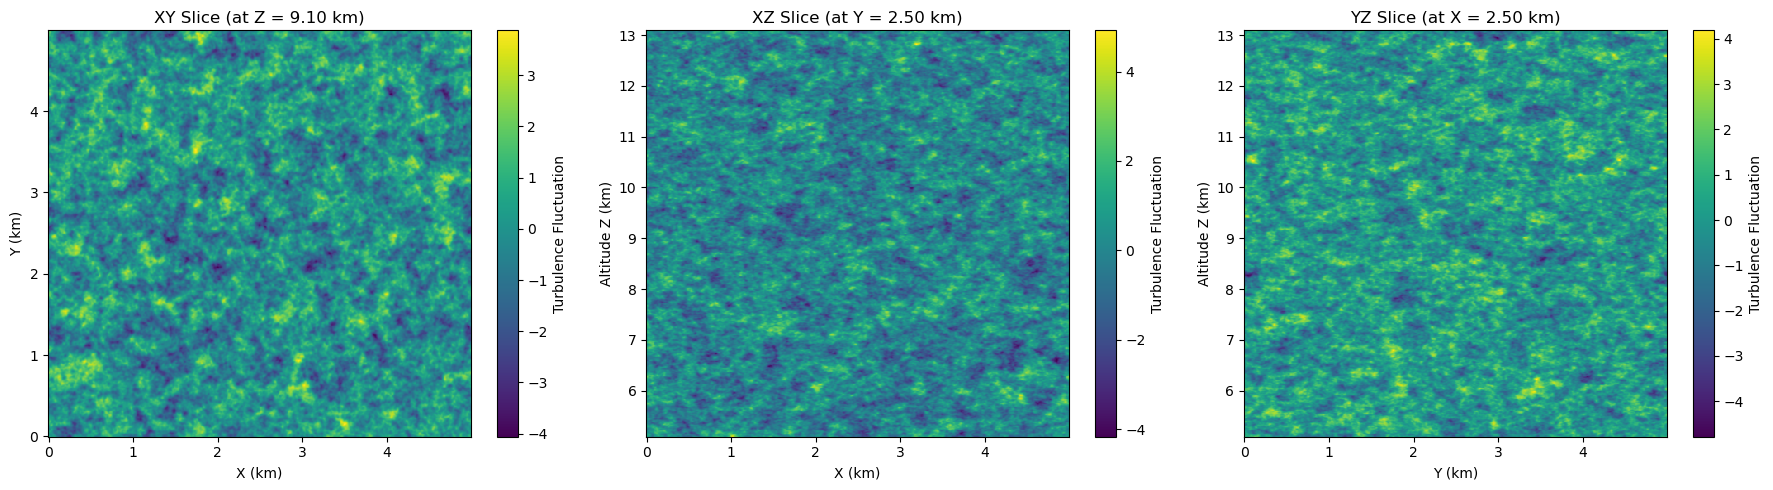

In [6]:
turbulence_field = cloud_box.field

# 1. Extract the physical axes directly from the atmo3 GridWorkspace (and convert to km)
x_axis_km = grid_wsp.grid_axis(axis=0) / 1000.0
y_axis_km = grid_wsp.grid_axis(axis=1) / 1000.0
z_axis_km = grid_wsp.grid_axis(axis=2, altitude_axis=True) / 1000.0

# 2. Find the middle indices using the native grid parameters
mid_x = grid_wsp.N[0] // 2
mid_y = grid_wsp.N[1] // 2
mid_z = grid_wsp.N[2] // 2

# 3. Extract the 2D slices at the center of the box
slice_xy = turbulence_field[:, :, mid_z]
slice_xz = turbulence_field[:, mid_y, :]
slice_yz = turbulence_field[mid_x, :, :]

# 4. Plot the slices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Note: plt.pcolormesh expects the data matrix to be oriented as (Y_dim, X_dim). 
# Since slice_xy is extracted as (Nx, Ny), we apply .T (transpose) to align it with the axes.

# --- XY Slice (Horizontal plane) ---
im1 = axes[0].pcolormesh(x_axis_km, y_axis_km, slice_xy.T, cmap='viridis', shading='auto')
axes[0].set_title(f'XY Slice (at Z = {z_axis_km[mid_z]:.2f} km)')
axes[0].set_xlabel('X (km)')
axes[0].set_ylabel('Y (km)')
fig.colorbar(im1, ax=axes[0], label='Turbulence Fluctuation')

# --- XZ Slice (Vertical plane along X) ---
im2 = axes[1].pcolormesh(x_axis_km, z_axis_km, slice_xz.T, cmap='viridis', shading='auto')
axes[1].set_title(f'XZ Slice (at Y = {y_axis_km[mid_y]:.2f} km)')
axes[1].set_xlabel('X (km)')
axes[1].set_ylabel('Altitude Z (km)')
fig.colorbar(im2, ax=axes[1], label='Turbulence Fluctuation')

# --- YZ Slice (Vertical plane along Y) ---
im3 = axes[2].pcolormesh(y_axis_km, z_axis_km, slice_yz.T, cmap='viridis', shading='auto')
axes[2].set_title(f'YZ Slice (at X = {x_axis_km[mid_x]:.2f} km)')
axes[2].set_xlabel('Y (km)')
axes[2].set_ylabel('Altitude Z (km)')
fig.colorbar(im3, ax=axes[2], label='Turbulence Fluctuation')

plt.tight_layout()
plt.show()

In [7]:

# --- Cloud Mask Generation ---

# 1. Get the vertical dimension size (Nz)
nz = turbulence_field.shape[2]

# 2. Flatten the horizontal spatial dimensions to shape (nz, nx * ny) 
# Transposing moves the Z-axis to index 0 so jax.vmap can map over the layers.
fluct_flat = jnp.transpose(turbulence_field, (2, 0, 1)).reshape(nz, -1)

# 3. Calculate target quantiles for each layer
# E.g., if cloud cover is 0.1 (10%), we cut at the 0.9 (90th) percentile.
q_targets = jnp.clip(1.0 - cloud_cover_ratio, 0.0, 1.0)

# 4. Vectorized quantile thresholding
# This efficiently computes the threshold amplitude for all layers simultaneously.
layer_thresholds = jax.vmap(jnp.quantile)(fluct_flat, q_targets)

# 5. Reshape the 1D arrays into 3D shapes for array broadcasting (1, 1, Nz)
thresholds_3d = layer_thresholds.reshape(1, 1, nz)
cc_3d = cloud_cover_ratio.reshape(1, 1, nz)

# 6. Create the binary mask
# A voxel becomes a cloud (1) ONLY IF its layer has a CC > 0 AND it beats the threshold.
cloud_mask_3d = jnp.where((cc_3d > 0.0) & (turbulence_field >= thresholds_3d), 1, 0).astype(jnp.int8)

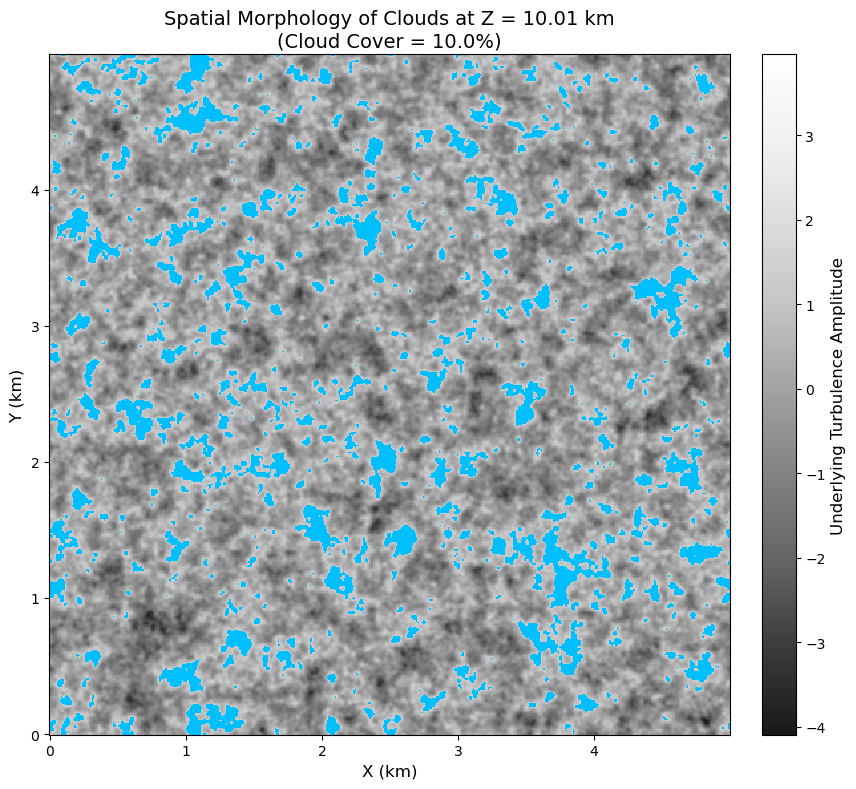

In [8]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# --- 1. Identify the Exact Slice ---
# Using the corrected peak_idx to ensure we slice exactly where the CC ratio is highest
desired_z_peak = 10000.0
peak_idx = jnp.argmin(jnp.abs(z_axis_grid - desired_z_peak))
actual_z_peak = z_axis_grid[peak_idx]
actual_cc = cloud_cover_ratio[peak_idx]

# --- 2. Extract Data & Convert for Matplotlib ---
# Extract the JAX slices and transpose them for pcolormesh (Y, X orientation)
slice_turb = np.array(turbulence_field[:, :, peak_idx]).T
slice_mask = np.array(cloud_mask_3d[:, :, peak_idx]).T

# Extract physical axes in km
x_axis_km = np.array(grid_wsp.grid_axis(axis=0)) / 1000.0
y_axis_km = np.array(grid_wsp.grid_axis(axis=1)) / 1000.0

# --- 3. Create the Transparency Mask ---
# Mask out all the 0s (clear sky) so only the 1s (clouds) get plotted in the foreground
cloud_overlay = np.ma.masked_where(slice_mask == 0, slice_mask)

# --- 4. Plotting ---
fig, ax = plt.subplots(figsize=(9, 8))

# Background: Plot the continuous turbulence in reversed grayscale (peaks are white/light gray)
im_turb = ax.pcolormesh(x_axis_km, y_axis_km, slice_turb, cmap='Greys_r', shading='auto', alpha=0.9)

# Foreground: Plot the binary cloud mask
# We use a custom single-color map to make the clouds a bright, distinct blue
cloud_cmap = mcolors.ListedColormap(['deepskyblue'])
im_cloud = ax.pcolormesh(x_axis_km, y_axis_km, cloud_overlay, cmap=cloud_cmap, shading='auto')

# Formatting
ax.set_title(f'Spatial Morphology of Clouds at Z = {actual_z_peak/1000:.2f} km\n(Cloud Cover = {actual_cc*100:.1f}%)', fontsize=14)
ax.set_xlabel('X (km)', fontsize=12)
ax.set_ylabel('Y (km)', fontsize=12)
ax.set_aspect('equal') # Forces the X and Y scales to be identical so clouds aren't stretched

# Add a colorbar for the turbulence to show the amplitude scale
cbar = fig.colorbar(im_turb, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Underlying Turbulence Amplitude', fontsize=12)

plt.tight_layout()
plt.show()

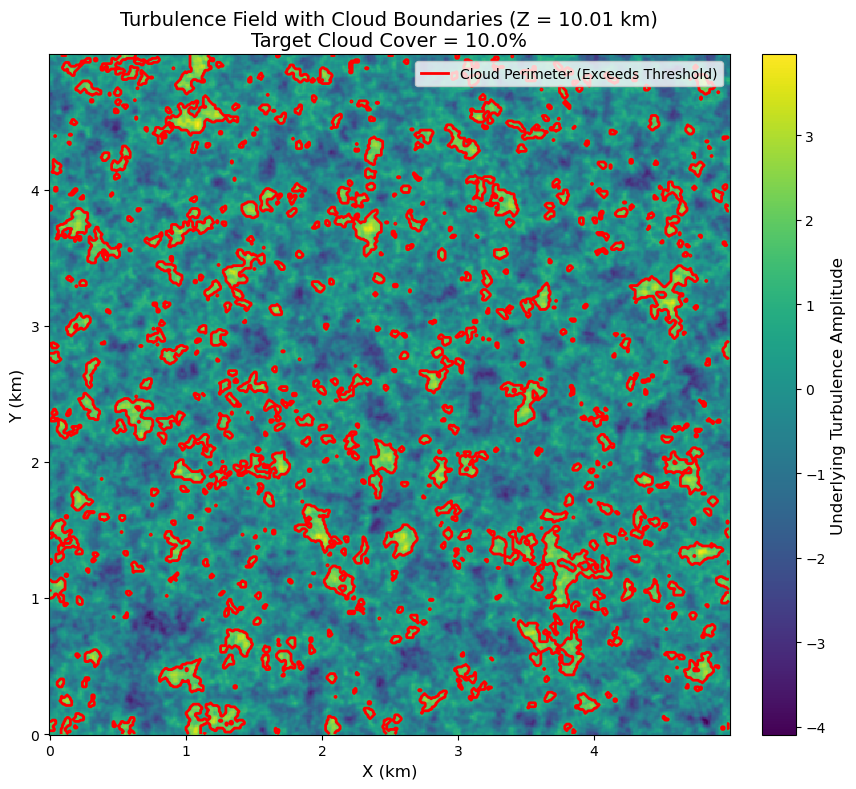

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Identify the Exact Slice ---
desired_z_peak = 10000.0
peak_idx = jnp.argmin(jnp.abs(z_axis_grid - desired_z_peak))
actual_z_peak = z_axis_grid[peak_idx]
actual_cc = cloud_cover_ratio[peak_idx]

# --- 2. Extract Data & Convert for Matplotlib ---
slice_turb = np.array(turbulence_field[:, :, peak_idx]).T
slice_mask = np.array(cloud_mask_3d[:, :, peak_idx]).T

x_axis_km = np.array(grid_wsp.grid_axis(axis=0)) / 1000.0
y_axis_km = np.array(grid_wsp.grid_axis(axis=1)) / 1000.0

# --- 3. Plotting ---
fig, ax = plt.subplots(figsize=(9, 8))

# Background: Plot the full continuous turbulence field in a vibrant colormap
im_turb = ax.pcolormesh(x_axis_km, y_axis_km, slice_turb, cmap='viridis', shading='auto')

# Foreground: Draw the red perimeter using plt.contour
# Since slice_mask only contains 0s and 1s, drawing a contour at 0.5 perfectly outlines the boundary
contour = ax.contour(x_axis_km, y_axis_km, slice_mask, levels=[0.5], colors='red', linewidths=2)

# Formatting
ax.set_title(f'Turbulence Field with Cloud Boundaries (Z = {actual_z_peak/1000:.2f} km)\nTarget Cloud Cover = {actual_cc*100:.1f}%', fontsize=14)
ax.set_xlabel('X (km)', fontsize=12)
ax.set_ylabel('Y (km)', fontsize=12)
ax.set_aspect('equal') # Prevents spatial stretching

# Add a colorbar for the turbulence amplitude
cbar = fig.colorbar(im_turb, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Underlying Turbulence Amplitude', fontsize=12)

# Create a custom legend entry for the red contour line
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='red', lw=2)]
ax.legend(custom_lines, ['Cloud Perimeter (Exceeds Threshold)'], loc='upper right')

plt.tight_layout()
plt.show()

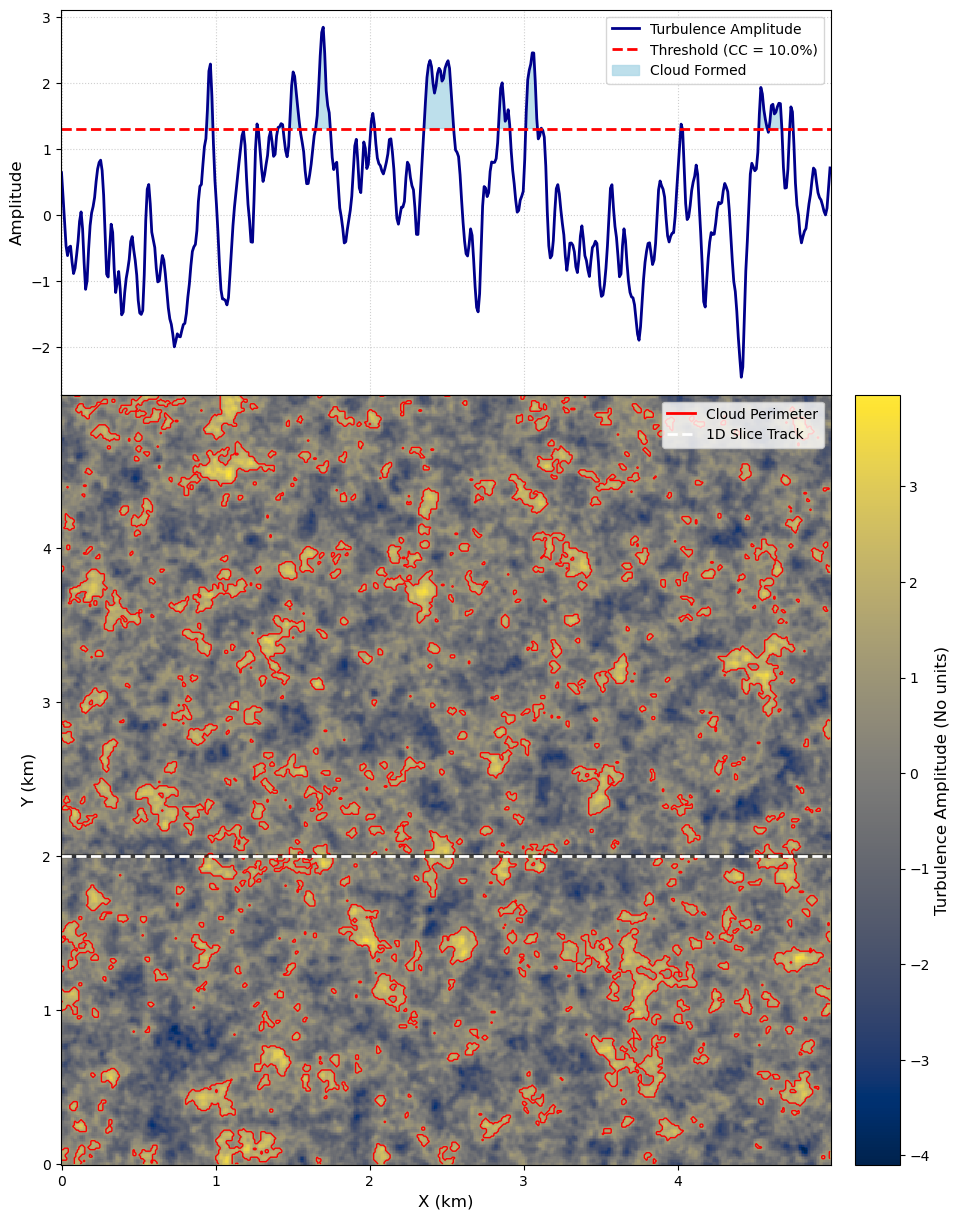

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# --- 1. Identify the Exact Slice ---
desired_z_peak = 10000.0
peak_idx = jnp.argmin(jnp.abs(z_axis_grid - desired_z_peak))
actual_z_peak = z_axis_grid[peak_idx]
actual_cc = cloud_cover_ratio[peak_idx]

layer_threshold = jnp.quantile(turbulence_field[:, :, peak_idx], 1.0 - actual_cc)

# --- 2. Extract Data for Matplotlib ---
x_axis_km = np.array(grid_wsp.grid_axis(axis=0)) / 1000.0
y_axis_km = np.array(grid_wsp.grid_axis(axis=1)) / 1000.0

turb_2d = np.array(turbulence_field[:, :, peak_idx])
mask_2d = np.array(cloud_mask_3d[:, :, peak_idx])

slice_y_km = 2.0
y_slice_idx = np.argmin(np.abs(y_axis_km - slice_y_km))
actual_slice_y = y_axis_km[y_slice_idx]

turb_1d = turb_2d[:, y_slice_idx]

# ==========================================
# --- 3. Layout Parameters ---
# ==========================================
# Decrease this value to pull the colorbar closer (e.g., 0.01). Increase to push it away.
colorbar_distance = -0.25

# --- 4. Plotting the Composite Figure ---
fig = plt.figure(figsize=(13, 15))

# Inject the colorbar_distance into wspace
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 0.04], height_ratios=[1, 2], wspace=colorbar_distance, hspace=0.0)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1) 
cax = fig.add_subplot(gs[1, 1])

# --- PANEL A: 1D Mechanism ---
ax1.plot(x_axis_km, turb_1d, color='darkblue', lw=2, label='Turbulence Amplitude')
ax1.axhline(layer_threshold, color='red', linestyle='--', lw=2, label=f'Threshold (CC = {actual_cc*100:.1f}%)')
ax1.fill_between(x_axis_km, layer_threshold, turb_1d, where=(turb_1d > layer_threshold), color='lightblue', alpha=0.8, label='Cloud Formed')

ax1.set_ylabel('Amplitude', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.6)

# Hide X-axis numbers for the top plot, but keep the line/ticks
ax1.tick_params(axis='x', labelbottom=False)

# --- PANEL B: 2D Morphology ---
im_turb = ax2.pcolormesh(x_axis_km, y_axis_km, turb_2d.T, cmap='cividis', shading='auto')

ax2.contour(x_axis_km, y_axis_km, mask_2d.T, levels=[0.5], colors='red', linewidths=1)
ax2.axhline(actual_slice_y, color='black', linestyle='-', linewidth=3, alpha=0.5) 
ax2.axhline(actual_slice_y, color='white', linestyle='--', linewidth=2)

ax2.set_xlabel('X (km)', fontsize=12)
ax2.set_ylabel('Y (km)', fontsize=12)
ax2.set_aspect('equal')

# --- Colorbar ---
cbar = fig.colorbar(im_turb, cax=cax)
cbar.set_label('Turbulence Amplitude (No units)', fontsize=12)

custom_lines = [Line2D([0], [0], color='red', lw=2),
                Line2D([0], [0], color='white', linestyle='--', lw=2)]
ax2.legend(custom_lines, ['Cloud Perimeter', '1D Slice Track'], loc='upper right')


# ==========================================
# --- THE ALIGNMENT MAGIC FIX ---
# ==========================================
plt.draw() 

pos2 = ax2.get_position()
pos1 = ax1.get_position()

ax1.set_position([pos2.x0, pos1.y0, pos2.width, pos1.height])
# ==========================================

plt.show()

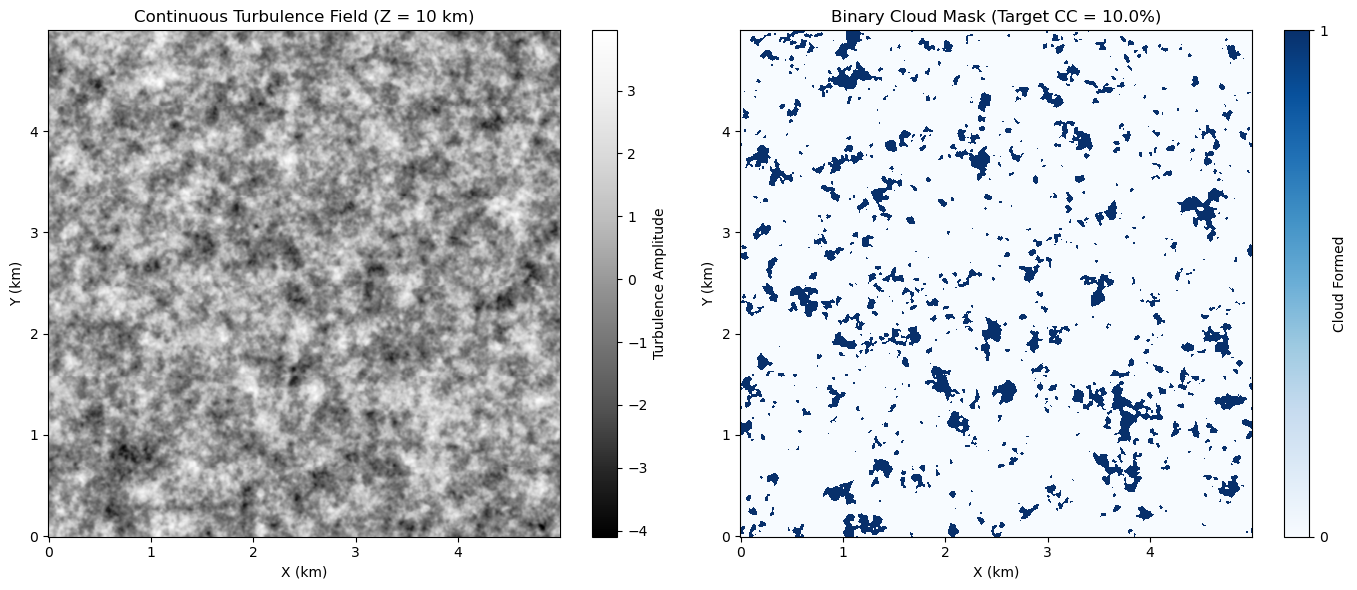

In [11]:
import matplotlib.pyplot as plt

# Find the exact index for your peak altitude (10 km)
# z_peak = 10000.0 from your previous definition
peak_index = jnp.argmin(jnp.abs(z_axis_grid - 10000.0))

# Extract the continuous turbulence and the resulting binary mask at Z = 10km
slice_turb = turbulence_field[:, :, peak_index]
slice_mask = cloud_mask_3d[:, :, peak_index]

# Extract physical X and Y axes for the plot
x_axis_km = grid_wsp.grid_axis(axis=0) / 1000.0
y_axis_km = grid_wsp.grid_axis(axis=1) / 1000.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: The underlying continuous turbulence
im1 = ax1.pcolormesh(x_axis_km, y_axis_km, slice_turb.T, cmap='Greys_r', shading='auto')
ax1.set_title('Continuous Turbulence Field (Z = 10 km)')
ax1.set_xlabel('X (km)')
ax1.set_ylabel('Y (km)')
fig.colorbar(im1, ax=ax1, label='Turbulence Amplitude')

# Plot 2: The thresholded clouds
# Using 'Blues' to make the clouds visually pop against a white background
im2 = ax2.pcolormesh(x_axis_km, y_axis_km, slice_mask.T, cmap='Blues', shading='auto', vmin=0, vmax=1)
ax2.set_title(f'Binary Cloud Mask (Target CC = {cloud_cover_ratio[peak_index]*100:.1f}%)')
ax2.set_xlabel('X (km)')
ax2.set_ylabel('Y (km)')
fig.colorbar(im2, ax=ax2, ticks=[0, 1], label='Cloud Formed')

plt.tight_layout()
plt.show()

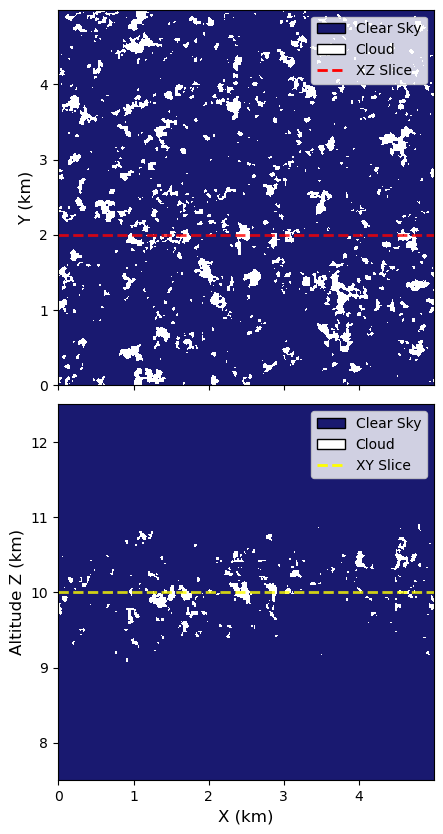

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# --- 1. User Parameters ---
desired_z_peak = 10000.0  # Altitude for the XY horizontal slice
slice_y_km = 2.0          # Y-coordinate for the XZ vertical slice
z_zoom_window_km = 5.0    # Total altitude range to display in the bottom plot

# --- 2. Extract Data & Indices ---
x_axis_km = np.array(grid_wsp.grid_axis(axis=0)) / 1000.0
y_axis_km = np.array(grid_wsp.grid_axis(axis=1)) / 1000.0
z_axis_km = np.array(z_axis_grid) / 1000.0

peak_idx = jnp.argmin(jnp.abs(z_axis_grid - desired_z_peak))
actual_z_peak = z_axis_km[peak_idx]

y_slice_idx = jnp.argmin(jnp.abs(y_axis_km - slice_y_km))
actual_slice_y = y_axis_km[y_slice_idx]

slice_xy = np.array(cloud_mask_3d[:, :, peak_idx]) 
slice_xz = np.array(cloud_mask_3d[:, y_slice_idx, :]) 

# --- 3. Define Colors and Legend Elements ---
sky_color = 'midnightblue'
cloud_color = 'white'
cloud_cmap = mcolors.ListedColormap([sky_color, cloud_color])

# Create custom legend icons for the colors
sky_patch = mpatches.Patch(facecolor=sky_color, edgecolor='black', label='Clear Sky')
cloud_patch = mpatches.Patch(facecolor=cloud_color, edgecolor='black', label='Cloud')

# Create custom legend lines for the slice tracks
xz_line = Line2D([0], [0], color='red', linestyle='--', lw=2, label='XZ Slice')
xy_line = Line2D([0], [0], color='yellow', linestyle='--', lw=2, label='XY Slice')

# --- 4. Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

# --- Top Panel: XY Horizontal Slice ---
ax1.pcolormesh(x_axis_km, y_axis_km, slice_xy.T, cmap=cloud_cmap, shading='auto')
ax1.axhline(actual_slice_y, color='red', linestyle='--', lw=2, alpha=0.8)

ax1.set_ylabel('Y (km)', fontsize=12)
ax1.set_aspect('equal')
# Pass the custom color patches AND the track line to the legend
ax1.legend(handles=[sky_patch, cloud_patch, xz_line], loc='upper right')

# --- Bottom Panel: XZ Vertical Slice ---
ax2.pcolormesh(x_axis_km, z_axis_km, slice_xz.T, cmap=cloud_cmap, shading='auto')
ax2.axhline(actual_z_peak, color='yellow', linestyle='--', lw=2, alpha=0.8)

# Zoom the Z-axis to center perfectly around the clouds
z_min = actual_z_peak - (z_zoom_window_km / 2.0)
z_max = actual_z_peak + (z_zoom_window_km / 2.0)
ax2.set_ylim(z_min, z_max)

ax2.set_xlabel('X (km)', fontsize=12)
ax2.set_ylabel('Altitude Z (km)', fontsize=12)
ax2.set_aspect('equal')
ax2.legend(handles=[sky_patch, cloud_patch, xy_line], loc='upper right')

# Use hspace to control the vertical gap between the plots if desired
plt.subplots_adjust(hspace=0.05)
plt.show()

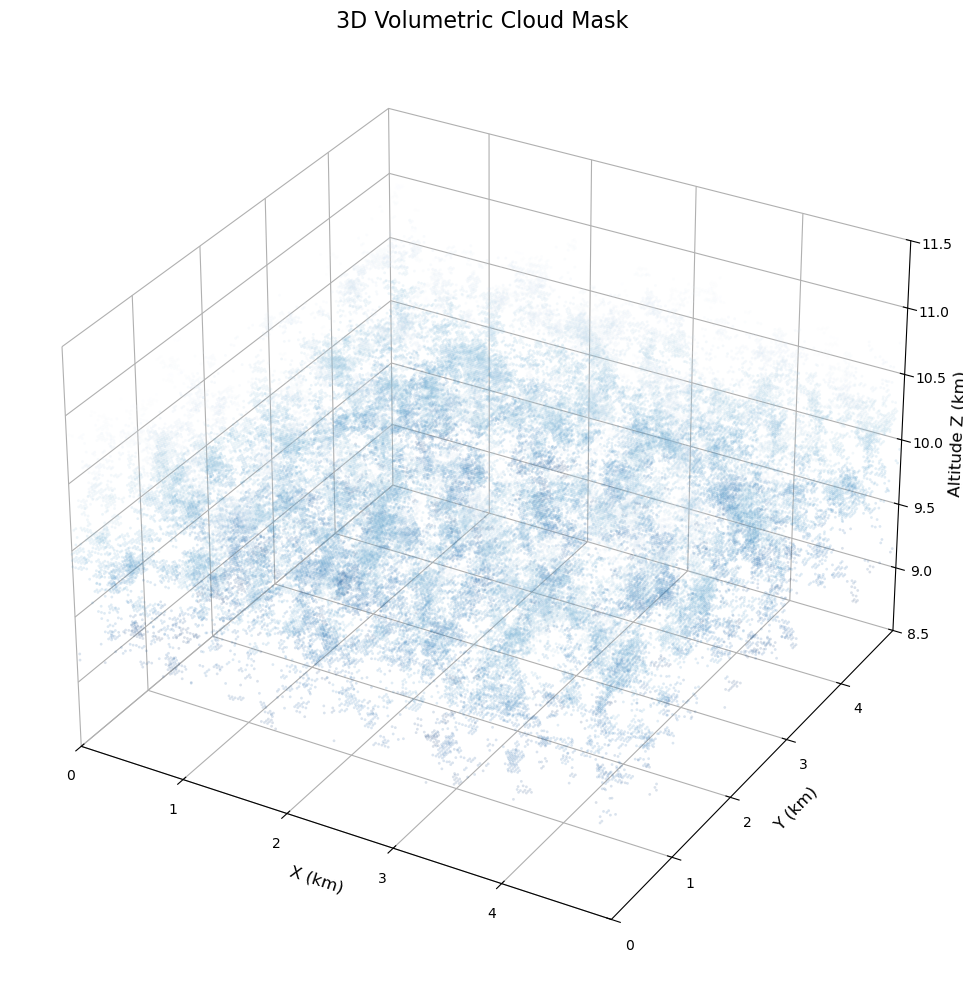

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. User Parameters ---
stride = 3           # Downsample step (Lower = more detail but slower)
point_size = 4.0     # Larger points for a thicker, fluffier look
point_alpha = 0.15   # Higher transparency so overlapping points build up density

desired_z_peak = 10000.0
z_zoom_window_km = 3.0

z_min_km = (desired_z_peak / 1000.0) - (z_zoom_window_km / 2.0)
z_max_km = (desired_z_peak / 1000.0) + (z_zoom_window_km / 2.0)

# --- 2. Extract and Filter ---
x_down = x_axis_km[::stride]
y_down = y_axis_km[::stride]
z_down = z_axis_km[::stride]
mask_downsampled = np.array(cloud_mask_3d[::stride, ::stride, ::stride])

idx_x, idx_y, idx_z = np.where(mask_downsampled == 1)
cloud_x = x_down[idx_x]
cloud_y = y_down[idx_y]
cloud_z = z_down[idx_z]

valid_z_mask = (cloud_z >= z_min_km) & (cloud_z <= z_max_km)
cloud_x = cloud_x[valid_z_mask]
cloud_y = cloud_y[valid_z_mask]
cloud_z = cloud_z[valid_z_mask]

# --- 3. Plotting with Faux-Illumination ---
# We use a clean white background so the shaded clouds pop out
fig = plt.figure(figsize=(10, 10), facecolor='white')
ax = fig.add_subplot(111, projection='3d', facecolor='white')

# THE MAGIC TRICK: We use the Z-coordinate to color the clouds.
# 'Blues_r' makes the bottom of the clouds dark blue/gray and the tops pure white.
scatter = ax.scatter(
    cloud_x, cloud_y, cloud_z, 
    c=cloud_z, cmap='Blues_r', 
    s=point_size, alpha=point_alpha, edgecolors='none'
)

ax.set_title('3D Volumetric Cloud Mask', fontsize=16)
ax.set_xlabel('X (km)', fontsize=12)
ax.set_ylabel('Y (km)', fontsize=12)
ax.set_zlabel('Altitude Z (km)', fontsize=12)

ax.set_xlim(x_axis_km[0], x_axis_km[-1])
ax.set_ylim(y_axis_km[0], y_axis_km[-1])
ax.set_zlim(z_min_km, z_max_km)

# Make the 3D pane walls completely transparent to remove the ugly gray box
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

plt.tight_layout()
plt.show()

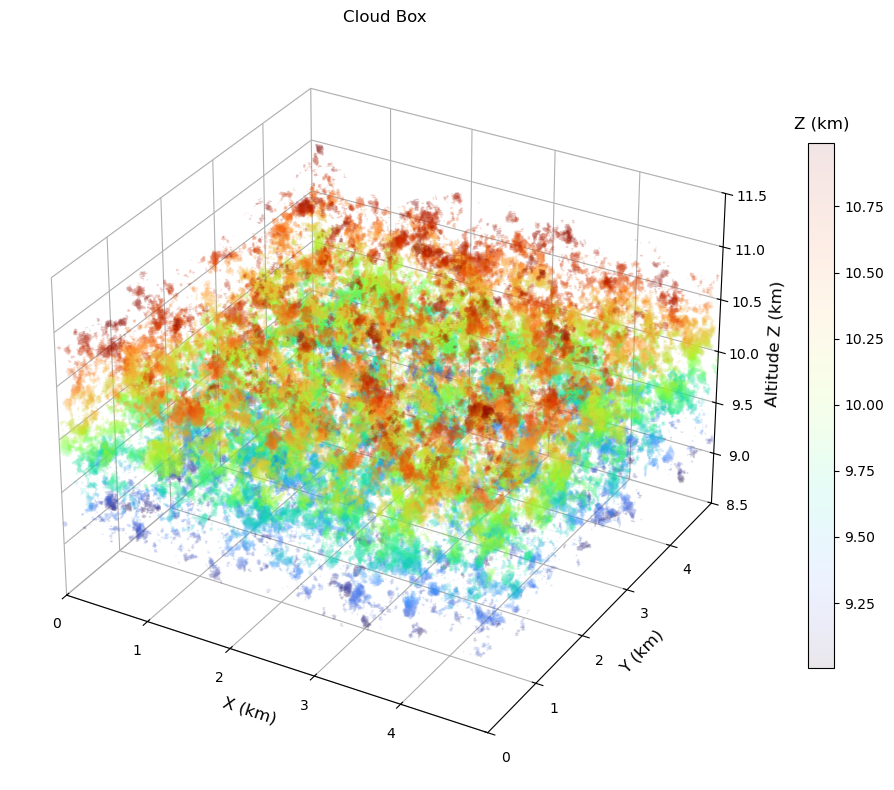

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. User Parameters ---
stride = 1           # Downsample step to prevent Matplotlib from crashing
point_size = 1.0     # From your previous code
point_alpha = 0.1   # From your previous code
colorbar_distance = 0.05  # Change this to adjust gap between plot and bar

desired_z_peak = 10000.0
z_zoom_window_km = 3.0

z_min_km = (desired_z_peak / 1000.0) - (z_zoom_window_km / 2.0)
z_max_km = (desired_z_peak / 1000.0) + (z_zoom_window_km / 2.0)

# --- 2. Extract, Downsample, and Filter ---
x_down = x_axis_km[::stride]
y_down = y_axis_km[::stride]
z_down = z_axis_km[::stride]
mask_downsampled = np.array(cloud_mask_3d[::stride, ::stride, ::stride])

# Extract the 3D coordinates where clouds exist (mask == 1)
idx_x, idx_y, idx_z = np.where(mask_downsampled == 1)
cloud_x = x_down[idx_x]
cloud_y = y_down[idx_y]
cloud_z = z_down[idx_z]

# Filter to only include points within our Z-window
valid_z_mask = (cloud_z >= z_min_km) & (cloud_z <= z_max_km)
cloud_x = cloud_x[valid_z_mask]
cloud_y = cloud_y[valid_z_mask]
cloud_z = cloud_z[valid_z_mask]

# --- 3. Plotting ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the 3D scatter points
sc = ax.scatter(cloud_x, cloud_y, cloud_z, c=cloud_z, cmap='turbo', 
                s=point_size, alpha=point_alpha, edgecolors='none')

# --- 4. Colorbar Positioning & Labeling ---
# Use pad to control the distance from the plot box
cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=colorbar_distance)

# Set the label above the colorbar
cbar.ax.set_title("Z (km)", fontsize=12, pad=10)

# --- 5. Formatting & Cleanup ---
# Remove Title
ax.set_title("Cloud Box") 

ax.set_xlabel('X (km)', fontsize=12)
ax.set_ylabel('Y (km)', fontsize=12)
ax.set_zlabel('Altitude Z (km)', fontsize=12)

# Set the background panes to be transparent
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# Adjust bounds
ax.set_xlim(x_axis_km[0], x_axis_km[-1])
ax.set_ylim(y_axis_km[0], y_axis_km[-1])
ax.set_zlim(z_min_km, z_max_km)

plt.tight_layout()
plt.show()

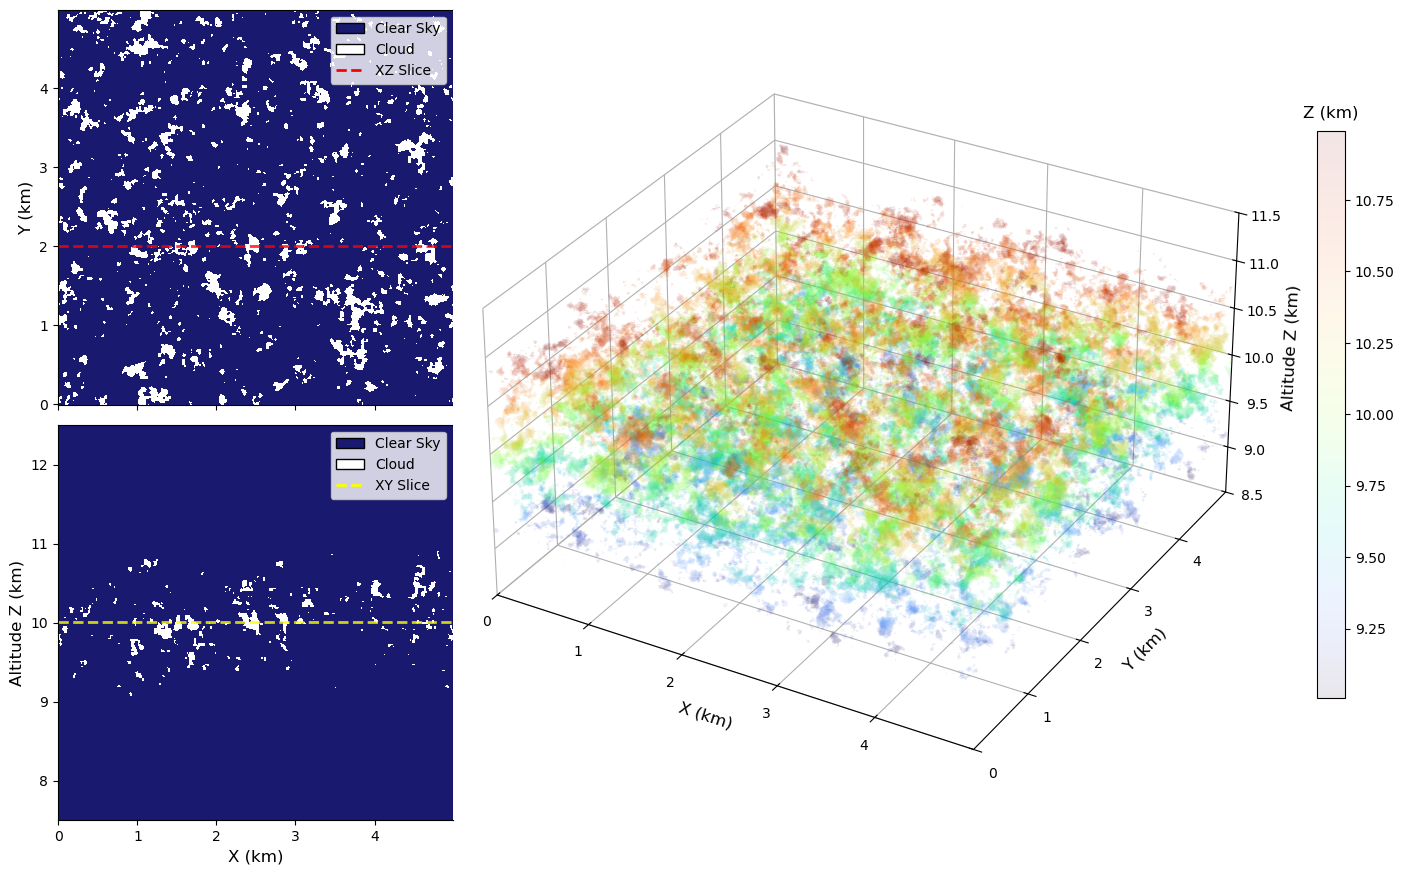

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

# ==========================================
# --- 1. User Parameters ---
# ==========================================
desired_z_peak = 10000.0  # Altitude for the slices and center of 3D cube
slice_y_km = 2.0          # Y-coordinate for the XZ vertical slice

# 2D Plot Parameters
z_zoom_window_2d = 5.0    # Altitude range for the bottom-left XZ slice

# 3D Plot Parameters
stride = 1                
point_size = 0.5          
point_alpha = 0.1         
z_zoom_window_3d = 3.0    
colorbar_distance = 0.05  

# --- NEW: Layout & Sizing Parameters ---
column_spacing = -0.1       # Decrease to bring left and right plots closer together (default was 0.05)
cube_width_ratio = 2.5    # Increase to give the 3D plot a wider section of the figure (e.g., 1.5, 1.8)
camera_distance = 0.5         # Decrease to zoom in on the 3D cube and reduce white margins (default is 10)

# ==========================================
# --- 2. Extract Data & Indices ---
# ==========================================
x_axis_km = np.array(grid_wsp.grid_axis(axis=0)) / 1000.0
y_axis_km = np.array(grid_wsp.grid_axis(axis=1)) / 1000.0
z_axis_km = np.array(z_axis_grid) / 1000.0

peak_idx = jnp.argmin(jnp.abs(z_axis_grid - desired_z_peak))
actual_z_peak = z_axis_km[peak_idx]

y_slice_idx = jnp.argmin(jnp.abs(y_axis_km - slice_y_km))
actual_slice_y = y_axis_km[y_slice_idx]

# 2D Slices
slice_xy = np.array(cloud_mask_3d[:, :, peak_idx]) 
slice_xz = np.array(cloud_mask_3d[:, y_slice_idx, :]) 

# 3D Extraction & Filtering
z_min_km_3d = (desired_z_peak / 1000.0) - (z_zoom_window_3d / 2.0)
z_max_km_3d = (desired_z_peak / 1000.0) + (z_zoom_window_3d / 2.0)

x_down = x_axis_km[::stride]
y_down = y_axis_km[::stride]
z_down = z_axis_km[::stride]
mask_downsampled = np.array(cloud_mask_3d[::stride, ::stride, ::stride])

idx_x, idx_y, idx_z = np.where(mask_downsampled == 1)
cloud_x = x_down[idx_x]
cloud_y = y_down[idx_y]
cloud_z = z_down[idx_z]

valid_z_mask = (cloud_z >= z_min_km_3d) & (cloud_z <= z_max_km_3d)
cloud_x = cloud_x[valid_z_mask]
cloud_y = cloud_y[valid_z_mask]
cloud_z = cloud_z[valid_z_mask]

# ==========================================
# --- 3. Define Legend Elements ---
# ==========================================
sky_color = 'midnightblue'
cloud_color = 'white'
cloud_cmap = mcolors.ListedColormap([sky_color, cloud_color])

sky_patch = mpatches.Patch(facecolor=sky_color, edgecolor='black', label='Clear Sky')
cloud_patch = mpatches.Patch(facecolor=cloud_color, edgecolor='black', label='Cloud')
xz_line = Line2D([0], [0], color='red', linestyle='--', lw=2, label='XZ Slice')
xy_line = Line2D([0], [0], color='yellow', linestyle='--', lw=2, label='XY Slice')

# ==========================================
# --- 4. Plotting & Grid Layout ---
# ==========================================
fig = plt.figure(figsize=(16, 9))

# Apply the new spacing and width ratio parameters here
gs = gridspec.GridSpec(2, 2, width_ratios=[1, cube_width_ratio], wspace=column_spacing, hspace=0.05)

ax1 = fig.add_subplot(gs[0, 0])                     
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)         
ax3 = fig.add_subplot(gs[:, 1], projection='3d')    

# ------------------------------------------
# --- Panel 1 (Top Left): XY Horizontal Slice
ax1.pcolormesh(x_axis_km, y_axis_km, slice_xy.T, cmap=cloud_cmap, shading='auto')
ax1.axhline(actual_slice_y, color='red', linestyle='--', lw=2, alpha=0.8)

ax1.set_ylabel('Y (km)', fontsize=12)
ax1.set_aspect('equal')
ax1.legend(handles=[sky_patch, cloud_patch, xz_line], loc='upper right')
ax1.tick_params(labelbottom=False) 

# ------------------------------------------
# --- Panel 2 (Bottom Left): XZ Vertical Slice
ax2.pcolormesh(x_axis_km, z_axis_km, slice_xz.T, cmap=cloud_cmap, shading='auto')
ax2.axhline(actual_z_peak, color='yellow', linestyle='--', lw=2, alpha=0.8)

z_min_2d = actual_z_peak - (z_zoom_window_2d / 2.0)
z_max_2d = actual_z_peak + (z_zoom_window_2d / 2.0)
ax2.set_ylim(z_min_2d, z_max_2d)

ax2.set_xlabel('X (km)', fontsize=12)
ax2.set_ylabel('Altitude Z (km)', fontsize=12)
ax2.set_aspect('equal')
ax2.legend(handles=[sky_patch, cloud_patch, xy_line], loc='upper right')

# ------------------------------------------
# --- Panel 3 (Right): 3D Volumetric Cloud Mask
sc = ax3.scatter(cloud_x, cloud_y, cloud_z, c=cloud_z, cmap='turbo', 
                 s=point_size, alpha=point_alpha, edgecolors='none')

ax3.set_xlabel('X (km)', fontsize=12)
ax3.set_ylabel('Y (km)', fontsize=12)
ax3.set_zlabel('Altitude Z (km)', fontsize=12)
#We define the title but we choose to put it a little bit lower
#ax3.set_title('Cloud Box', fontsize=14, pad=-150)  # Adjust pad to move title down

# Set 3D bounds
ax3.set_xlim(x_axis_km[0], x_axis_km[-1])
ax3.set_ylim(y_axis_km[0], y_axis_km[-1])
ax3.set_zlim(z_min_km_3d, z_max_km_3d)

x_range = x_axis_km[-1] - x_axis_km[0]
y_range = y_axis_km[-1] - y_axis_km[0]
z_range_3d = z_max_km_3d - z_min_km_3d
try:
    ax3.set_box_aspect((x_range, y_range, z_range_3d))
except AttributeError:
    pass 

# Transparent panes
ax3.xaxis.pane.fill = False
ax3.yaxis.pane.fill = False
ax3.zaxis.pane.fill = False

# Zoom in the camera to make the cube physically larger
ax3.dist = camera_distance

# Colorbar for the 3D plot
cbar = plt.colorbar(sc, ax=ax3, shrink=0.7, pad=colorbar_distance)
cbar.ax.set_title("Z (km)", fontsize=12, pad=10)

plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
plt.show()